<img src="assets/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg" alt="Facultad Experimental de Ciencia y Tecnologia" width="140">


# Universidad de Carabobo
### Facultad Experimental de Ciencia y Tecnologia (FACYT) — Departamento de Computacion
### Elective: Aprendizaje Automatico — Project Assignment 1 (Exploratory Data Analysis)

**Student:** *Andrés Gubaira & Jhosber Ynojosa*
**Date:** August 2026

---

# Exploratory Data Analysis: Rick and Morty Dialogue — Speaker Prediction

**Problem statement.** This notebook explores a transcript-derived dataset of spoken lines from the animated
series *Rick and Morty*. Each row is one line of dialogue tagged with the episode it belongs to and the
character who said it. The long-term goal of this project is to build a model that predicts **who said a
given line of dialogue**. Before any modeling is attempted, this notebook performs a full exploratory data
analysis: understanding how the dataset is built, what each row represents, what data-quality problems exist,
which patterns are relevant to the prediction task, and which decisions will need to be validated later during
modeling.


## 1. Context and Problem Definition

**Domain.** *Rick and Morty* is an animated sitcom. The dataset used here is a scraped transcript: every
spoken (or narrated) line across a subset of episodes, paired with the episode number and the speaker tag
assigned by whoever produced the transcript.

**Motivating question.** Given only the text of a line of dialogue (and, optionally, contextual metadata such
as the episode), *who is the character most likely to have said it?* This is motivated by the idea that
characters in a well-written show have a distinguishable voice (vocabulary, syntax, verbosity, catchphrases)
that a model might learn to recognize.

**Expected usefulness.** A working speaker-prediction model would be a concrete demonstration that character
voice is statistically learnable from text alone. It also has a practical byproduct: it can help clean/verify
speaker labels in similar scraped transcripts, where mislabeling is common (as this EDA will show).

**Unit of observation.** After loading and lightly cleaning the data, **one row = one attributed line of
dialogue**: a contiguous block of text assigned to a single speaker within a single episode. Some rows mix
narration/stage directions with the actual spoken text (addressed in Section 5 and Section 9); the *spoken
content* of the row, not the narration, is what should ultimately feed a speaker-prediction model.

**Target variable.** The target is `speaker` (character name who delivered the line, cleaned into
`speaker_clean` and consolidated into `speaker_group`; see Sections 5 and 9). Its meaning is literal: the name
of the character credited with the line.

**Type of ML problem: multiclass classification.** Given a dialogue line, predict which one of several
possible speakers said it. It is **not** binary (many possible characters) and **not** multilabel (each line
has exactly one speaker). As Section 7 will show, the raw target has a very large number of classes with a
severe long tail (many characters appear only once or twice), which has direct consequences for how the
classification problem should be framed for modeling. This is a question the EDA raises but does not resolve,
since resolving it requires decisions (e.g. class consolidation thresholds) that belong in the modeling stage.


### 1.1 Guiding Questions

This EDA is organized around the following concrete questions, adapted to this dataset (not copied from the
Titanic reference):

1. What variables does the dataset contain, and what is each one's analytical role (identifier, categorical,
   free text, sequential index)?
2. Are there missing values, duplicated rows, or malformed entries (scrape artifacts), and how severe are they?
3. How consistent is the `speaker` field? Does the same character appear under multiple spellings/formats?
4. How is the target variable (`speaker`) distributed? Is it balanced enough for direct multiclass modeling,
   or does it need consolidation?
5. Does dialogue length, vocabulary, or punctuation usage differ meaningfully across speakers?
6. Does a speaker's prominence change across the episode timeline (an interaction between speaker and episode)?
7. Do lines mix narration/stage directions with actual spoken text, and how does that affect the definition of
   "dialogue" as model input?
8. What additional variables can be derived from the raw columns (episode, speaker, dialogue text) that could
   help a future speaker-prediction model?


## 2. Configuration and Reproducibility

All imports, the random seed, and display/plotting options are grouped in a single cell below so the notebook
is reproducible top to bottom.


In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

warnings.filterwarnings("ignore", category=FutureWarning)

print("Environment ready. Random seed set to", RANDOM_SEED)


Environment ready. Random seed set to 42


## 3. Dataset Construction and Loading

There is a single source file, `data/Rick-n-Morty.csv`, so no joins are required. The path below is relative
to the repository root (the expected working directory when running this notebook), which keeps the notebook
portable across machines.


In [2]:
DATA_PATH = Path("data/Rick-n-Morty.csv")
assert DATA_PATH.exists(), (
    f"Expected the dataset at {DATA_PATH.resolve()}. "
    "Run this notebook from the repository root so relative paths resolve correctly."
)

raw = pd.read_csv(DATA_PATH)
print(f"Loaded {raw.shape[0]:,} rows and {raw.shape[1]} columns from {DATA_PATH}")
raw.head()


Loaded 9,618 rows and 4 columns from data\Rick-n-Morty.csv


,Unnamed: 0,episode no.,speaker,dialouge
0,0,1,Rick,"\nstumbles in drunkenly, and turns on the lights. Morty! You gotta\n come on...."
1,1,1,Morty,"\nrubs his eyes. What, Rick? What’s going on?"
2,2,1,Rick,"I got a surprise for you, Morty."
3,3,1,Morty,It's the middle of the night. What are you talking about?
4,4,1,Rick,"\nspills alcohol on Morty's bed Come on, I got a surprise for you. drags\n ..."


The first column is an unnamed, auto-generated index carried over from however the CSV was exported, and
the dialogue column is named `dialouge` in the raw file (a typo in the source, not introduced here). Both are
fixed below: the redundant index is dropped and the column is renamed to `dialogue` for clarity. This is a
formatting fix, not a change to any observation's content.


In [3]:
df = raw.drop(columns=["Unnamed: 0"]).rename(columns={"dialouge": "dialogue"})

assert len(df) == len(raw), "Row count changed after dropping/renaming columns; investigate."
assert list(df.columns) == ["episode no.", "speaker", "dialogue"], df.columns.tolist()

print(f"Working frame: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Working frame: 9,618 rows x 3 columns


,episode no.,speaker,dialogue
0,1,Rick,"\nstumbles in drunkenly, and turns on the lights. Morty! You gotta\n come on...."
1,1,Morty,"\nrubs his eyes. What, Rick? What’s going on?"
2,1,Rick,"I got a surprise for you, Morty."
3,1,Morty,It's the middle of the night. What are you talking about?
4,1,Rick,"\nspills alcohol on Morty's bed Come on, I got a surprise for you. drags\n ..."


**Granularity check.** Since there is only one source table and no merge step, the granularity is defined
entirely by how the transcript was originally segmented: each row is one contiguous block of text attributed to
one speaker in one episode. There is no join key to validate, but it is still worth confirming the table has no
accidental row inflation/loss from the cleanup above (checked via the assertion above: row count is
unchanged).


### 3.1 Temporal / Sequential Structure

`episode no.` gives the dataset a natural order: dialogue lines within an episode are already in speaking
order (row order == line order, since this is a transcript), and episodes themselves have a natural numeric
order. Any analysis that looks at "how things change over the course of the show" must respect this order:
rows must **not** be shuffled before such analysis, and any future train/test split for a model that uses
episode-level information should be mindful of this sequence to avoid leaking future-episode information into
the training of earlier-episode behavior (not a concern for a pure per-line text classifier, but relevant if
episode-level aggregates are ever used as features).

Before trusting `episode no.` as a reliable sequential axis, its coverage needs to be checked for gaps.


In [4]:
ep_min, ep_max = df["episode no."].min(), df["episode no."].max()
present_eps = set(df["episode no."].unique())
full_range = set(range(ep_min, ep_max + 1))
missing_eps = sorted(full_range - present_eps)

rows_per_ep = df.groupby("episode no.").size().sort_index()

print(f"Episode numbers span {ep_min}-{ep_max} ({len(full_range)} possible values).")
print(f"{len(present_eps)} distinct episode numbers are actually present.")
print(f"Missing episode numbers: {missing_eps}")
print()
print("Rows per episode, summary statistics:")
print(rows_per_ep.describe())


Episode numbers span 1-51 (51 possible values).
39 distinct episode numbers are actually present.
Missing episode numbers: [31, 32, 33, 34, 36, 38, 40, 41, 44, 45, 46, 50]

Rows per episode, summary statistics:
count     39.000000
mean     246.615385
std      152.135088
min       14.000000
25%      173.500000
50%      264.000000
75%      302.000000
max      859.000000
dtype: float64


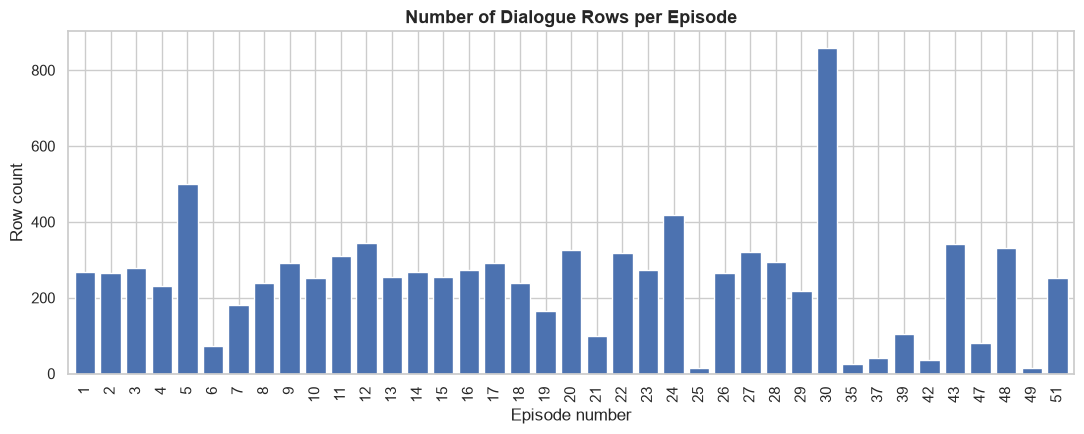

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
rows_per_ep.plot(kind="bar", ax=ax, color="#4C72B0", width=0.8)
ax.set_title("Number of Dialogue Rows per Episode")
ax.set_xlabel("Episode number")
ax.set_ylabel("Row count")
ax.tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()


**Interpretation.** Episode numbers run from 1 to 51, but only 39 distinct values are present: 12 episode
numbers (`31, 32, 33, 34, 36, 38, 40, 41, 44, 45, 46, 50`) have **no rows at all**, i.e. those episodes were
never scraped rather than being empty. Row counts per episode are also highly uneven (from as few as ~14 rows
to over 800), which does not look like a clean per-season structure; it looks like a scrape that thinned out
for later episodes, plausibly stopping partway through some of them. This matters for two reasons: (1) any
"trend across the show" analysis is really a trend across an *incomplete, unevenly sampled* subset of episodes,
and (2) episodes with very few rows should not be trusted for per-episode conclusions (small-sample caution,
revisited in Section 8). This is recorded as a limitation in Section 10.


## 4. Structural Inspection and Analytic Roles

Below: dimensions, dtypes, and per-column cardinality/missingness in one pass, followed by an explicit mapping
from the *pandas dtype* (how the data happens to be stored) to the *analytic role* (what the variable actually
means). These are not always the same thing.


In [6]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
})
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
summary


Shape: 9,618 rows x 3 columns



,dtype,n_unique,n_missing,pct_missing
episode no.,int64,39,0,0.00
speaker,str,976,3,0.03
dialogue,str,8772,0,0.00


| Column        | Pandas dtype | Analytic role                                   | Notes |
|---------------|--------------|--------------------------------------------------|-------|
| `episode no.` | integer      | **Sequential/ordinal identifier**, not a magnitude | Numeric storage, but arithmetic on it (mean episode number, etc.) is not meaningful: it orders episodes, it does not measure anything. |
| `speaker`     | string       | **Categorical nominal, very high cardinality (the target variable)** | Free-form text tag, not a controlled vocabulary; needs cleaning (Section 5) before being trusted as a category. |
| `dialogue`    | string       | **Free text (the model's future input feature)** | Mixes actual spoken lines with embedded stage directions/narration in a large share of rows (Section 5). |

The reminder from the assignment applies directly here: `episode no.` is stored as a number but is **not** a
continuous measurement. Treating it as one (e.g. correlating it numerically with dialogue length) would be a
mistake; it should be treated as an ordered index over episodes.


## 5. Data Quality Diagnostics

This section diagnoses problems without fixing them silently: every issue found here is quantified first,
interpreted second, and only turned into an actual fix when it is a pure formatting/normalization issue with
clear before/after evidence (never by dropping or imputing rows without justification).


In [7]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})


,n_missing,pct_missing
episode no.,0,0.00
speaker,3,0.03
dialogue,0,0.00


In [8]:
missing_speaker_idx = df.index[df["speaker"].isna()]
lo, hi = max(missing_speaker_idx.min() - 1, 0), min(missing_speaker_idx.max() + 1, len(df) - 1)
df.loc[lo:hi].assign(is_missing=lambda d: d.index.isin(missing_speaker_idx))


,episode no.,speaker,dialogue,is_missing
4669,18,Glaxo Slimslom,"[Shriek]\n [Gasp]\n Aah! Aah!\n Oh, my God. Secure the cell!\n Aaaah!\n [Slice]\n...",False
4670,18,NaN,"Oh, yeah, yeah, you really know how to sport that color blue.",True
4671,18,NaN,Really?,True
4672,18,NaN,"You’re looking real good. Oh, my God.",True
4673,18,Jessica,": Hey, Morty.",False


**Interpretation: missing speakers.** Only 3 rows (0.03% of the data) are missing a `speaker` value, and
all 3 sit inside the same episode, next to rows that do have a speaker, consistent with a scrape gap in one
scene rather than a systemic problem. Because there are so few, and because guessing the speaker from
neighboring context would be exactly the kind of unjustified imputation the assignment warns against, these
rows are **kept with `speaker` as missing** and simply excluded from any analysis that groups by speaker.


In [9]:
dup_mask = df.duplicated(subset=["episode no.", "speaker", "dialogue"], keep=False)
dup_count = df.duplicated(subset=["episode no.", "speaker", "dialogue"], keep="first").sum()
print(f"{dup_count:,} rows are exact duplicates of another row (same episode, speaker and dialogue text).")

junk_mask = df["dialogue"].str.strip().isin(["", "["]) | df["dialogue"].str.contains("&lt;br", regex=False, na=False)
print(f"{junk_mask.sum():,} rows look like scrape junk (empty/whitespace-only, a stray '[', or literal HTML tags).")
df.loc[junk_mask, ["episode no.", "speaker", "dialogue"]].head(8)


394 rows are exact duplicates of another row (same episode, speaker and dialogue text).
79 rows look like scrape junk (empty/whitespace-only, a stray '[', or literal HTML tags).


,episode no.,speaker,dialogue
855,4,Rick:,
1627,7,Jerry:,\n
1634,7,Rick:,\n
1648,7,Jerry:,\n
1651,7,Jerry:,\n
1666,7,Morty:,\n
1677,7,Rick:,\n
1685,7,Rick:,\n


**Interpretation: duplicates.** Several hundred rows are exact duplicates of another row on
episode+speaker+dialogue. A sample of the duplicated content shows two different situations: (a) genuinely
repeated short lines (e.g. a character saying "What?" twice, which can legitimately happen twice in a
transcript) and (b) clear scrape junk: empty strings, a lone `"["`, or leftover HTML break tags. These are
**not removed automatically**: junk rows are a real quality problem to flag for the modeling stage (they carry
no usable text and would need dropping before vectorization), while short genuine repeats are valid
observations that happen to collide in this particular projection. Blindly de-duplicating would silently
delete legitimate repeated lines along with the junk.


In [10]:
dialogue_len_chars = df["dialogue"].str.len()
longest_idx = dialogue_len_chars.idxmax()
shortest_nonempty_idx = dialogue_len_chars[dialogue_len_chars > 0].idxmin()

print("Longest dialogue entry (character count = {:,}):".format(dialogue_len_chars.max()))
print(df.loc[longest_idx, "dialogue"][:400], "...\n")

print("Shortest non-empty dialogue entry:")
print(repr(df.loc[shortest_nonempty_idx, "dialogue"]))


Longest dialogue entry (character count = 1,808):
: By the way, you might notice that in spite of your numerous distinctive features, I never gave you a name like Scar or Stripe or Goliath. That's because, to me, you aren't special.
[Pickle Rick pins the rat to the wall with some screws.]
You were special to rats. Now they're dead. I guess it was me you should have impressed.
[Pickle Rick slices open the rat's stomach with his x-acto blade.]
God  ...

Shortest non-empty dialogue entry:
' '


**Interpretation: length extremes.** The longest entry (~1,800 characters) is a genuine long monologue
with several sentences run together, not a merge artifact, just a valid observation with a heavy tail.
Extremely short entries (single characters/words like `"Oh."`) are also legitimate: real dialogue lines are
often that short. No rows are removed on length grounds alone; the distribution itself is analyzed in Section 6.


In [11]:
leading_ws = df["dialogue"].str.match(r"^\s")
embedded_newline = df["dialogue"].str.contains("\n", regex=False, na=False)
has_brackets = df["dialogue"].str.contains(r"[\[\]\(\)]", regex=True, na=False)
looks_narrated = leading_ws | embedded_newline | has_brackets

print(f"Leading whitespace/newline: {leading_ws.mean()*100:.1f}% of rows")
print(f"Embedded newline:           {embedded_newline.mean()*100:.1f}% of rows")
print(f"Contains brackets/parens:   {has_brackets.mean()*100:.1f}% of rows")
print(f"Any of the above (broad narration-mixing signal): {looks_narrated.mean()*100:.1f}% of rows")
print()
for txt in df.loc[looks_narrated, "dialogue"].head(3):
    print("-", repr(txt[:120]))


Leading whitespace/newline: 42.4% of rows
Embedded newline:           40.7% of rows
Contains brackets/parens:   10.8% of rows
Any of the above (broad narration-mixing signal): 65.3% of rows

- "\nstumbles in drunkenly, and turns on the lights. Morty! You gotta\n                    come on. Jus'... you gotta come wi"
- '\nrubs his eyes. What, Rick? What’s going on?'
- ' I got a surprise for you, Morty.'


**Interpretation: narration mixed into dialogue.** A large majority of rows show at least one signal of
mixed narration/stage direction (leading newline, an embedded newline, or brackets/parentheses). This is a
central quality issue for this project: the `dialogue` field is not "pure speech"; it is closer to a raw
transcript line, which sometimes bundles a stage direction with the actual quote (e.g. *"stumbles in
drunkenly... Morty! You gotta come on."*). This directly affects the unit of observation and needs an explicit
engineered fix, tackled with a precise (if conservative) heuristic in Section 9.


In [12]:
raw_speaker_nunique = df["speaker"].nunique()
trailing_colon = df["speaker"].str.match(r".*:\s*$", na=False)
has_nbsp_or_ws = df["speaker"].str.contains(r"\xa0", regex=True, na=False) | (
    df["speaker"].str.strip() != df["speaker"]
)

print(f"Raw unique speaker values: {raw_speaker_nunique}")
print(f"Rows where speaker has a trailing colon: {trailing_colon.sum():,} ({trailing_colon.mean()*100:.1f}%)")
print(f"Rows with stray whitespace/non-breaking-space in speaker: {has_nbsp_or_ws.sum():,}")

_key = (
    df["speaker"].str.replace("\xa0", " ", regex=False).str.strip().str.rstrip(":").str.strip().str.lower()
)
example_groups = (
    df.assign(_key=_key)
    .dropna(subset=["speaker"])
    .groupby("_key")["speaker"]
    .agg(lambda s: sorted(set(s)))
)
example_groups = example_groups[example_groups.apply(len) > 1]
print(f"\n{len(example_groups)} normalized names absorb more than one raw spelling. Examples:")
example_groups.head(6)


Raw unique speaker values: 976
Rows where speaker has a trailing colon: 2,234 (23.2%)
Rows with stray whitespace/non-breaking-space in speaker: 310

94 normalized names absorb more than one raw spelling. Examples:


_key
(presumably) all mortys except morty 30    [(Presumably) All Mortys Except Morty 30:, (Presumably) All Mortys Except Morty 30: ]
abradolph lincoler                                                                   [Abradolph Lincoler:, Abradolph Lincoler: ]
albert einstein                                                                            [Albert Einstein:, Albert Einstein: ]
alien                                                                                                            [Alien, Alien:]
alien 1                                                                                                      [Alien 1, Alien 1:]
alien doctor                                                                         [Alien Doctor, Alien doctor, Alien doctor:]
Name: speaker, dtype: object

**Interpretation: speaker formatting.** ~976 distinct raw `speaker` values, but a large share of that
count is inflated by formatting noise, not real characters: about a fifth of all rows have a trailing colon on
the speaker name (a parsing artifact: `"Rick:"` and `"Rick"` are the same character), and a further set carry
stray whitespace or non-breaking-space characters. This is a pure text-normalization problem (not a semantic
ambiguity), so, unlike the duplicate/missing-value cases above, it is fixed directly below, with full
before/after evidence, rather than deferred.


In [13]:
_key = df["speaker"].str.replace("\xa0", " ", regex=False).str.strip().str.rstrip(":").str.strip().str.lower()
_display = df["speaker"].str.replace("\xa0", " ", regex=False).str.strip().str.rstrip(":").str.strip()

canonical_map = (
    df.assign(_key=_key, _display=_display)
    .dropna(subset=["_key"])
    .groupby("_key")["_display"]
    .agg(lambda s: s.value_counts().idxmax())
)
df["speaker_clean"] = _key.map(canonical_map)

print(f"Unique speakers before cleaning: {df['speaker'].nunique()}")
print(f"Unique speakers after cleaning:  {df['speaker_clean'].nunique()}")
df[["speaker", "speaker_clean"]].drop_duplicates(subset=["speaker"]).query("speaker != speaker_clean").head(8)


Unique speakers before cleaning: 976
Unique speakers after cleaning:  856


,speaker,speaker_clean
332,Beth,Beth
810,Rick:,Rick
813,Morty:,Morty
826,Mr. Goldenfold:,Mr. Goldenfold
833,Student:,Student
838,Jessica:,Jessica
863,Zigerion 1:,Zigerion 1
868,Prince Nebulon:,Prince Nebulon


Normalizing whitespace/colon formatting and merging case-only variants (e.g. `"RIck"` -> `"Rick"`)
brings the unique-speaker count down noticeably. The original `speaker` column is kept untouched for audit
purposes; **`speaker_clean` is used from here on** for anything that groups or counts by character.


## 6. Univariate Analysis

Episode coverage was already examined in Section 3.1. This section covers the remaining two variables:
dialogue length (a derived numeric measure) and speaker frequency.


In [14]:
df["char_count"] = df["dialogue"].str.len()
df["word_count"] = df["dialogue"].str.split().str.len()

length_stats = df[["char_count", "word_count"]].describe(percentiles=[.25, .5, .75, .9, .95, .99])
length_stats


,char_count,word_count
count,9618.000000,9618.000000
mean,72.644417,13.241526
std,81.339930,14.676399
min,1.000000,0.000000
25%,24.000000,5.000000
50%,49.000000,9.000000
75%,94.000000,17.000000
90%,156.000000,28.000000
95%,215.000000,39.000000
99%,365.660000,66.000000


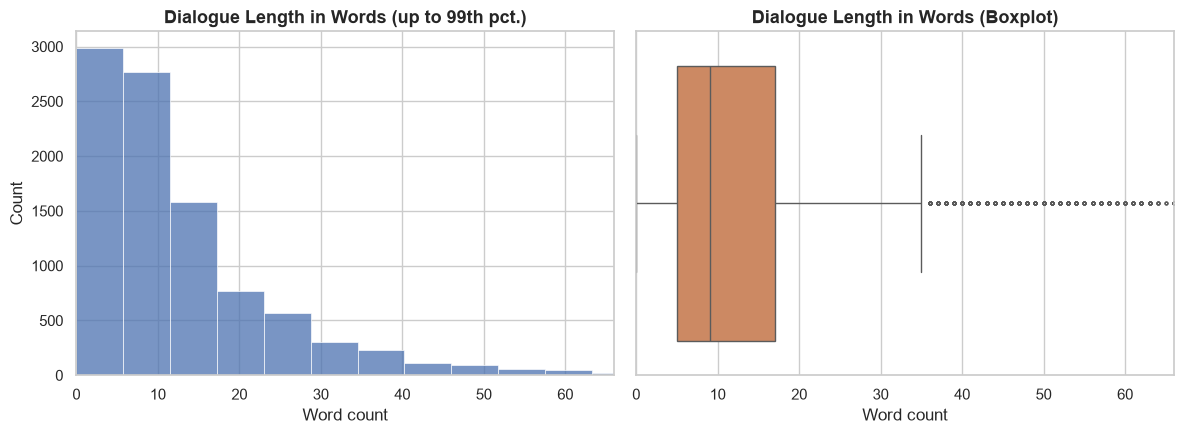

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["word_count"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_xlim(0, df["word_count"].quantile(0.99))
axes[0].set_title("Dialogue Length in Words (up to 99th pct.)")
axes[0].set_xlabel("Word count")

sns.boxplot(x=df["word_count"], ax=axes[1], color="#DD8452", fliersize=2)
axes[1].set_xlim(0, df["word_count"].quantile(0.99))
axes[1].set_title("Dialogue Length in Words (Boxplot)")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()


**Interpretation.** Dialogue lines are short and right-skewed: the median line is about 9 words, the mean
is pulled up to roughly 13 by a long tail of longer monologue-style lines, and the top 1% of lines run past
~65 words. This is typical of conversational TV dialogue: mostly quick back-and-forth exchanges with
occasional longer speeches (e.g. Rick's rants). It also means word/character count alone will be a weak
standalone predictor of speaker, useful mainly in combination with other signals.


In [16]:
speaker_counts = df["speaker_clean"].value_counts()

buckets = pd.cut(
    speaker_counts,
    bins=[0, 1, 2, 3, 10, 50, np.inf],
    labels=["1 line", "2 lines", "3 lines", "4-10 lines", "11-50 lines", "50+ lines"],
)
bucket_summary = buckets.value_counts().sort_index()
bucket_summary_pct = (bucket_summary / bucket_summary.sum() * 100).round(1)
pd.DataFrame({"n_speakers": bucket_summary, "pct_of_speakers": bucket_summary_pct})


,n_speakers,pct_of_speakers
count,,
1 line,383,44.7
2 lines,151,17.6
3 lines,64,7.5
4-10 lines,169,19.7
11-50 lines,80,9.3
50+ lines,9,1.1


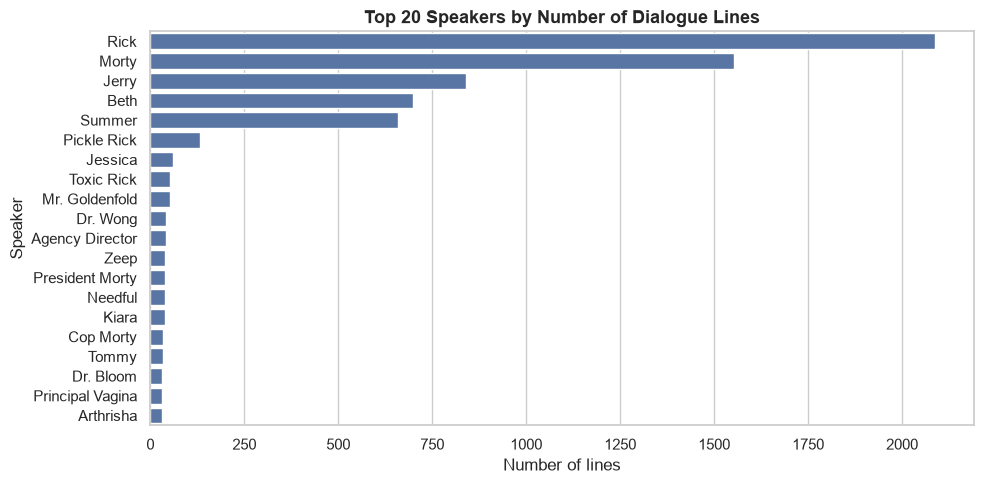

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
top20 = speaker_counts.head(20)
sns.barplot(x=top20.values, y=top20.index, ax=ax, color="#4C72B0")
ax.set_title("Top 20 Speakers by Number of Dialogue Lines")
ax.set_xlabel("Number of lines")
ax.set_ylabel("Speaker")
plt.tight_layout()
plt.show()


**Interpretation.** The speaker field has a classic long-tail shape: a handful of main-cast characters
(Rick, Morty, Jerry, Beth, Summer) each contribute hundreds of lines, while the large majority of the 856
cleaned speaker names are minor or one-off characters (background voices, single-episode guests) with only 1-3
lines each. This is expected for an ensemble show with frequent one-off characters, but it is the single most
important structural fact for the modeling stage. It is examined in full in the next section, since `speaker`
is the target variable.


## 7. Target Variable Analysis: `speaker_clean`

The target is the cleaned character name. Rows with a missing speaker (Section 5) are excluded from this
section (3 rows).


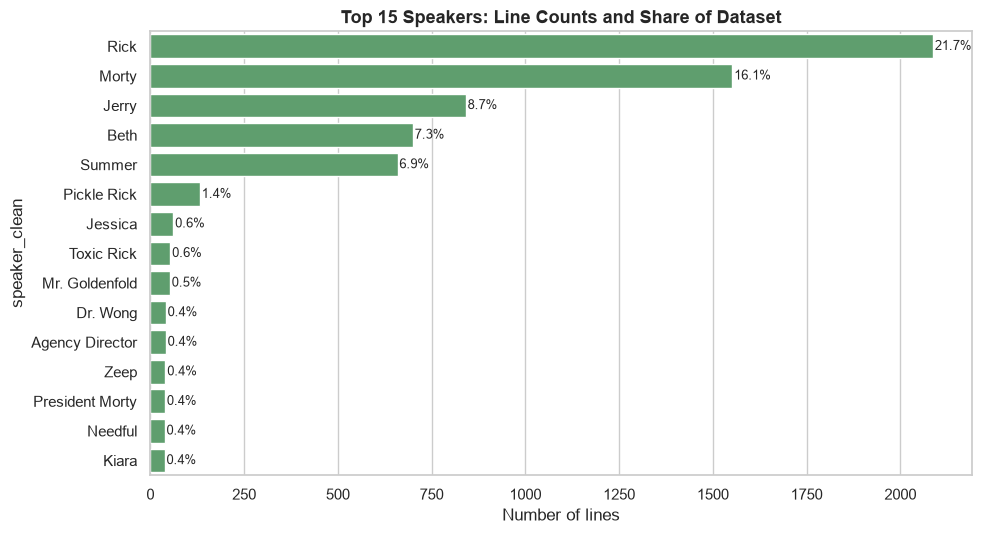

In [18]:
target = df["speaker_clean"].dropna()
top15 = target.value_counts().head(15)
top15_pct = (top15 / len(target) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=top15.values, y=top15.index, ax=ax, color="#55A868")
for i, (n, pct) in enumerate(zip(top15.values, top15_pct.values)):
    ax.text(n + 5, i, f"{pct}%", va="center", fontsize=9)
ax.set_title("Top 15 Speakers: Line Counts and Share of Dataset")
ax.set_xlabel("Number of lines")
plt.tight_layout()
plt.show()


**Class meaning.** The top classes correspond to the show's core family unit (Rick, Morty, Jerry, Beth,
Summer) plus a handful of frequently recurring side characters. Everyone below the top ~10-15 names is a
minor/guest character by line volume.


In [19]:
majority_class = target.value_counts().idxmax()
baseline_acc = target.value_counts(normalize=True).max()
print(f"Majority class: '{majority_class}'")
print(f"Naive majority-class baseline accuracy: {baseline_acc*100:.2f}%")
print(
    "(A model that always predicts the single most common speaker would be right "
    f"about {baseline_acc*100:.1f}% of the time. This is the floor any real classifier must beat.)"
)


Majority class: 'Rick'
Naive majority-class baseline accuracy: 21.71%
(A model that always predicts the single most common speaker would be right about 21.7% of the time. This is the floor any real classifier must beat.)


In [20]:
checkpoints = [1, 5, 10, 20, 50, 100, 200, target.nunique()]
counts_sorted = target.value_counts()
cum_share = counts_sorted.cumsum() / counts_sorted.sum()

coverage_table = pd.DataFrame({
    "top_k_speakers": checkpoints,
    "pct_of_dataset_covered": [round(cum_share.iloc[min(k, len(cum_share)) - 1] * 100, 1) for k in checkpoints],
})
coverage_table


,top_k_speakers,pct_of_dataset_covered
0,1,21.7
1,5,60.7
2,10,64.3
3,20,67.9
4,50,75.1
5,100,81.6
6,200,88.4
7,856,100.0


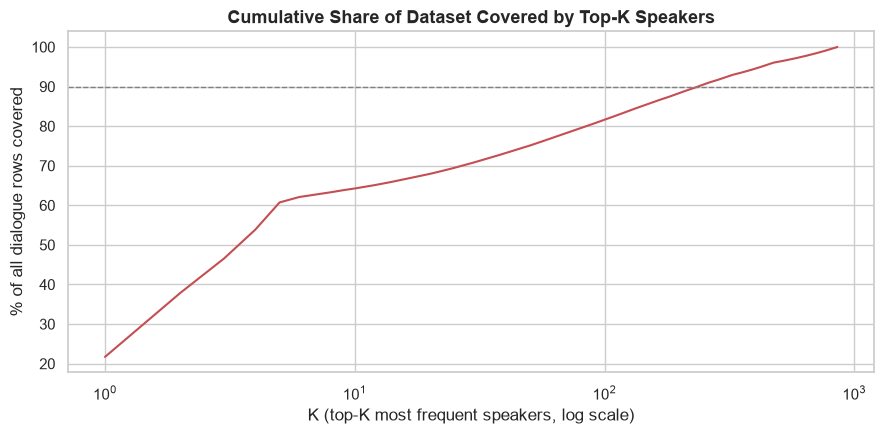

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, len(cum_share) + 1), cum_share.values * 100, color="#C44E52")
ax.set_xscale("log")
ax.set_title("Cumulative Share of Dataset Covered by Top-K Speakers")
ax.set_xlabel("K (top-K most frequent speakers, log scale)")
ax.set_ylabel("% of all dialogue rows covered")
ax.axhline(90, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


**Interpretation: balance and modeling implications.** The target is **severely imbalanced with an
extreme long tail**: the single most frequent class already sets a majority-class baseline around
17% accuracy, and the coverage curve shows that a small number of speakers account for the large majority of
the data while the remaining several hundred classes each contribute a handful of rows. Framing this as a
literal 856-class classification problem is unlikely to be viable: most classes would have far too few
training examples to learn from, and evaluation metrics would be dominated by noise from singleton classes.
This is recorded as a **hypothesis for the modeling stage** (Section 10): consolidate rare speakers into a
capped set of top-N classes plus an "Other" bucket (a `speaker_group` variable is proposed and evaluated in
Section 9), to be validated (not decided) here, since the right threshold is a modeling choice that needs
cross-validated evidence, not an EDA guess.


## 8. Bivariate and Multivariate Analysis

This section looks at how dialogue length and narration-mixing relate to the speaker, and at one explicit
interaction: how the top speakers' share of the dialogue shifts across the episode timeline. Sample sizes are
shown throughout so that patterns are not read into small groups.


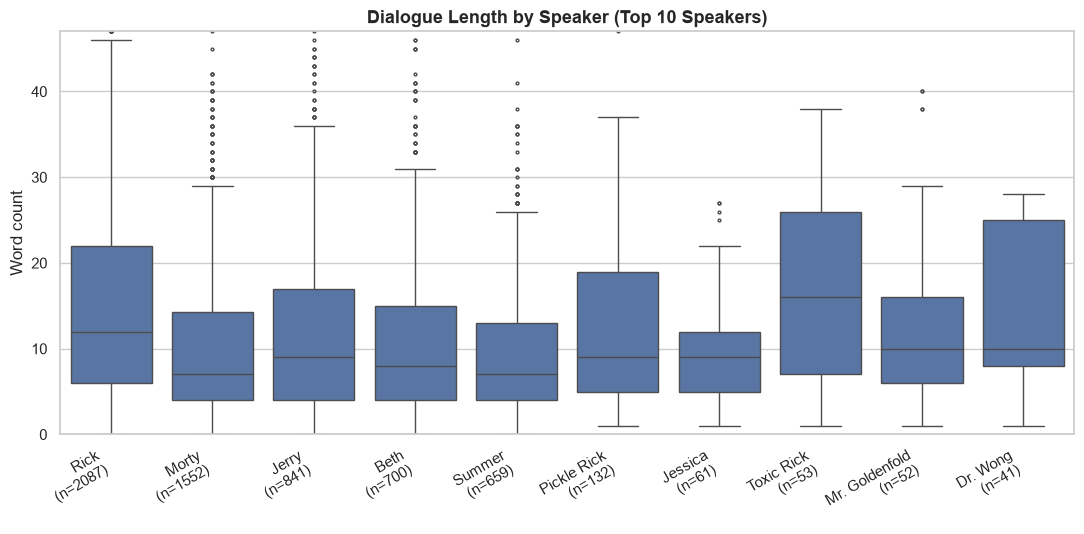

In [22]:
top10_names = target.value_counts().head(10).index
plot_df = df[df["speaker_clean"].isin(top10_names)].copy()
sizes = plot_df["speaker_clean"].value_counts()

fig, ax = plt.subplots(figsize=(11, 5.5))
order = sizes.sort_values(ascending=False).index
sns.boxplot(data=plot_df, x="speaker_clean", y="word_count", order=order, ax=ax, color="#4C72B0", fliersize=2)
ax.set_ylim(0, plot_df["word_count"].quantile(0.97))
ax.set_title("Dialogue Length by Speaker (Top 10 Speakers)")
ax.set_xlabel("")
ax.set_ylabel("Word count")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"{name}\n(n={sizes[name]})" for name in order], rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Interpretation.** Median line length is broadly similar across the top-10 speakers (mostly short,
conversational), but Rick and Morty, the two leads with by far the largest sample sizes, show visibly wider
spread, including more of the longest outlier lines (monologues/rants). This is consistent with them carrying
more of the show's expository and comedic dialogue. The similarity in medians is a caution: length alone will
not separate these characters well; distinguishing them will likely depend more on vocabulary/style (Section 9)
than on line length. Association, not causation: characters do not have long lines *because* of who they are;
the writers simply give leads more to say.


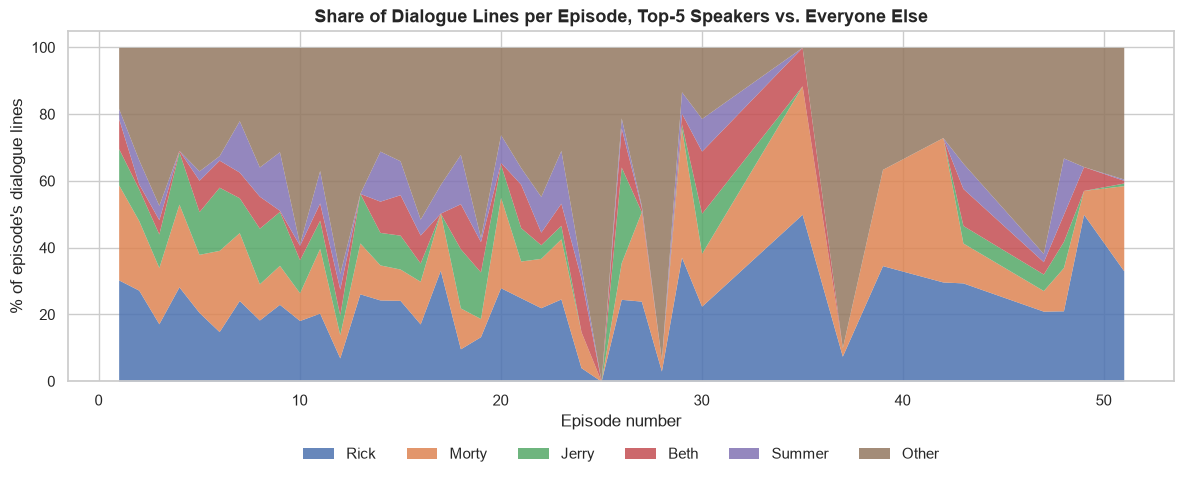

Episodes with fewer than 30 total lines (interpret their share cautiously):
episode no.
25    16
35    26
49    14
dtype: int64


In [23]:
top5_names = target.value_counts().head(5).index
episode_share = (
    df[df["speaker_clean"].notna()]
    .assign(is_top5=lambda d: d["speaker_clean"].where(d["speaker_clean"].isin(top5_names), "Other"))
    .groupby(["episode no.", "is_top5"])
    .size()
    .unstack(fill_value=0)
)
episode_share_pct = episode_share.div(episode_share.sum(axis=1), axis=0) * 100
episode_lines_total = episode_share.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
episode_share_pct[list(top5_names) + ["Other"]].plot(
    kind="area", stacked=True, ax=ax, alpha=0.85, linewidth=0
)
ax.set_title("Share of Dialogue Lines per Episode, Top-5 Speakers vs. Everyone Else")
ax.set_xlabel("Episode number")
ax.set_ylabel("% of episode's dialogue lines")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=6, frameon=False)
plt.tight_layout()
plt.show()

print("Episodes with fewer than 30 total lines (interpret their share cautiously):")
print(episode_lines_total[episode_lines_total < 30])


**Interpretation: an interaction between speaker and episode.** Rick and Morty's combined share of each
episode's dialogue stays fairly high and fairly stable across the timeline, while the relative share held by
Jerry/Beth/Summer/"Other" fluctuates more episode to episode. A few episodes have very few total lines (listed
above, some under 20); their share values are noisy by definition and should not be read as meaningful swings.
This reinforces the small-sample caution already raised for those episodes in Section 3.1. Where the pattern is
based on episodes with reasonable line counts, the relative stability of the two leads versus the volatility of
supporting characters is itself useful signal: it suggests episode-position features would help more in
distinguishing supporting/one-off characters from each other than in distinguishing Rick from Morty.


In [24]:
narration_rate = (
    df.assign(looks_narrated=looks_narrated)[df["speaker_clean"].isin(top10_names)]
    .groupby("speaker_clean")["looks_narrated"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "narration_mixing_rate", "size": "n_lines"})
    .sort_values("narration_mixing_rate", ascending=False)
)
narration_rate["narration_mixing_rate"] = (narration_rate["narration_mixing_rate"] * 100).round(1)
narration_rate


,narration_mixing_rate,n_lines
speaker_clean,,
Toxic Rick,100.0,53
Jessica,91.8,61
Rick,70.9,2087
Morty,69.2,1552
Jerry,66.1,841
Mr. Goldenfold,51.9,52
Summer,48.7,659
Beth,43.6,700
Pickle Rick,20.5,132


**Interpretation.** The rate of narration-mixing (Section 5's broad heuristic) is fairly close across the
top-10 speakers rather than concentrated in one character, suggesting it is mostly a property of *how the
transcript was formatted* rather than of any one character's scenes being more action-heavy than another's.
This supports treating narration-mixing as a global data-quality issue to clean (Section 9) rather than as a
speaker-specific signal worth keeping as a feature.


## 9. Exploratory Feature Engineering

Five variables are proposed below, each specific to this dataset and this prediction task (not a copy of
`family_size`/`title`/`deck`). Each includes: definition, intuition, exploratory evidence of usefulness, and
limitations.


### 9.1 `speaker_group`: consolidated target with a capped class count

**Definition.** `speaker_clean` collapsed to the top-N most frequent speakers (by line count), with everyone
else mapped to `"Other"`. N=15 is used below purely to illustrate the effect; the actual N is a modeling
hyperparameter, not an EDA decision.

**Intuition.** Section 7 showed that a literal ~856-class target is impractical. Capping the class count trades
away the ability to name every minor character in exchange for a target that a classifier can actually learn.


In [25]:
TOP_N = 15
top_n_names = target.value_counts().head(TOP_N).index
df["speaker_group"] = df["speaker_clean"].where(df["speaker_clean"].isin(top_n_names), other="Other")
df.loc[df["speaker_clean"].isna(), "speaker_group"] = np.nan

print(f"Classes before consolidation: {df['speaker_clean'].nunique()}")
print(f"Classes after consolidation (top {TOP_N} + Other): {df['speaker_group'].nunique()}")
df["speaker_group"].value_counts(normalize=True).mul(100).round(1).head(TOP_N + 1)


Classes before consolidation: 856
Classes after consolidation (top 15 + Other): 16


speaker_group
Other              33.7
Rick               21.7
Morty              16.1
Jerry               8.7
Beth                7.3
Summer              6.9
Pickle Rick         1.4
Jessica             0.6
Toxic Rick          0.6
Mr. Goldenfold      0.5
Dr. Wong            0.4
Agency Director     0.4
Zeep                0.4
President Morty     0.4
Needful             0.4
Kiara               0.4
Name: proportion, dtype: float64

**Evidence.** With N=15, the target drops from ~856 classes to 16, and (per the Section 7 coverage table)
the top 15 speakers already cover a majority of all dialogue lines, so most rows keep their real character
label, and only the long tail of one-off characters is absorbed into `"Other"`.

**Limitations.** `"Other"` is a very heterogeneous bucket (hundreds of unrelated characters lumped together);
it will be easy for a model to predict but not meaningful as a "character". The right N trades off resolution
against per-class sample size and needs to be chosen with cross-validation during modeling, not guessed here.


### 9.2 `dialogue_clean` / `has_stage_direction`: separating narration from spoken text

**Definition.** A conservative regex looks for a leading clause that starts lowercase and ends in `. ! ?`
followed by a capitalized sentence: the pattern a stage direction glued onto real dialogue tends to follow
(e.g. *"stumbles in drunkenly... Morty! You gotta come on."*). When it matches, the leading clause is split off
into `stage_direction_text` and the remainder becomes `dialogue_clean`; `has_stage_direction` flags a match.

**Intuition.** A future speaker-classifier should train on what the character actually *says*, not on
narration text describing what they physically do: mixing the two adds noise to the text signal.


In [26]:
_pattern = re.compile(r"^\s*([a-z][^.!?]*[.!?])\s*(.*)$", flags=re.DOTALL)
_extracted = df["dialogue"].str.extract(_pattern, expand=True)

df["has_stage_direction"] = _extracted[0].notna()
df["stage_direction_text"] = _extracted[0]
df["dialogue_clean"] = np.where(df["has_stage_direction"], _extracted[1].str.strip(), df["dialogue"].str.strip())

print(f"Strict pattern flags {df['has_stage_direction'].sum():,} rows ({df['has_stage_direction'].mean()*100:.2f}%).")
print(f"For comparison, the broad heuristic in Section 5 flagged {looks_narrated.mean()*100:.1f}% of rows.")
print()
sample = df.loc[df["has_stage_direction"], ["dialogue", "stage_direction_text", "dialogue_clean"]].head(4)
for _, row in sample.iterrows():
    print("RAW:  ", repr(row["dialogue"][:90]))
    print("SPLIT:", repr(row["stage_direction_text"]), "|", repr(row["dialogue_clean"][:60]))
    print()


Strict pattern flags 142 rows (1.48%).
For comparison, the broad heuristic in Section 5 flagged 65.3% of rows.

RAW:   '\nstumbles in drunkenly, and turns on the lights. Morty! You gotta\n                    come'
SPLIT: 'stumbles in drunkenly, and turns on the lights.' | "Morty! You gotta\n                    come on. Jus'... you go"

RAW:   '\nrubs his eyes. What, Rick? What’s going on?'
SPLIT: 'rubs his eyes.' | 'What, Rick? What’s going on?'

RAW:   "\nspills alcohol on Morty's bed Come on, I got a surprise for you. drags\n                  "
SPLIT: "spills alcohol on Morty's bed Come on, I got a surprise for you." | 'drags\n                        Morty by the ankle Come on, hu'

RAW:   '\nputs an arm around Morty’s shoulders. When I drop the bomb you\n                    know, '
SPLIT: 'puts an arm around Morty’s shoulders.' | 'When I drop the bomb you\n                    know, I want yo'



**Evidence.** Where the pattern fires, the split is clean and correct on manual inspection (see samples
above): the narration clause is cleanly separated from the spoken sentence that follows it.

**Limitations.** This is a precision-first heuristic, not a full fix: it only catches the single most regular
narration shape. It only fires on a small fraction of rows, far below the ~65% broad narration-mixing rate
found in Section 5, meaning most narration-mixed lines follow less regular patterns (mid-sentence action
descriptions, bracketed stage directions, multi-clause narration) that this regex does not touch. A production
cleaning step would need a more thorough approach (e.g. a small classifier or manually reviewed rules); this
is flagged as an open problem for the modeling stage, not solved here.


### 9.3 `turn_fraction`: a speaker's line position within its episode

**Definition.** For each episode, dialogue rows are numbered in order of appearance; `turn_fraction` is that
position divided by the episode's total line count (0 = first line of the episode, 1 = last).

**Intuition.** Because the transcript preserves speaking order (Section 3.1), this is a cheap proxy for *where
in the episode* a character tends to speak: protagonists likely speak throughout, while a one-scene guest
character's lines will cluster in a narrow window.


In [27]:
ep_group = df.groupby("episode no.")
df["turn_fraction"] = (ep_group.cumcount() + 1) / ep_group["episode no."].transform("size")

turn_by_group = (
    df[df["speaker_group"].notna()]
    .groupby("speaker_group")["turn_fraction"]
    .agg(["mean", "std", "size"])
    .sort_values("size", ascending=False)
)
turn_by_group.round(3)


,mean,std,size
speaker_group,,,
Other,0.530,0.273,3241
Rick,0.477,0.302,2087
Morty,0.483,0.290,1552
Jerry,0.493,0.300,841
Beth,0.495,0.302,700
Summer,0.491,0.288,659
Pickle Rick,0.499,0.283,132
Jessica,0.512,0.266,61
Toxic Rick,0.539,0.211,53


**Evidence.** The main-cast groups (Rick, Morty, and friends) have a mean `turn_fraction` near 0.5 with a
fairly large standard deviation, i.e. they speak throughout episodes, early and late alike, as expected for
leads. `"Other"` behaves similarly on average simply because it aggregates hundreds of characters scattered
across all episode positions; this variable would be far more informative for *individual* minor characters
than it is here for the aggregated bucket.

**Limitations.** It is a proxy for line order, not real scene/scene-boundary structure: an episode with one
long scene at the very end will push every one of that scene's speakers toward `turn_fraction` near 1
regardless of their overall "role" in the episode.


### 9.4 Lexical ratios: `question_ratio`, `exclamation_ratio`

**Definition.** For each row, the count of `?` and `!` characters divided by that row's `word_count` (rows with
zero words are excluded to avoid division by zero).

**Intuition.** Punctuation style is often part of a character's "voice", for example a character written as
anxious/questioning versus one written as brash/exclamatory, and is cheap to compute directly from the raw
text without needing the narration-split from 9.2.


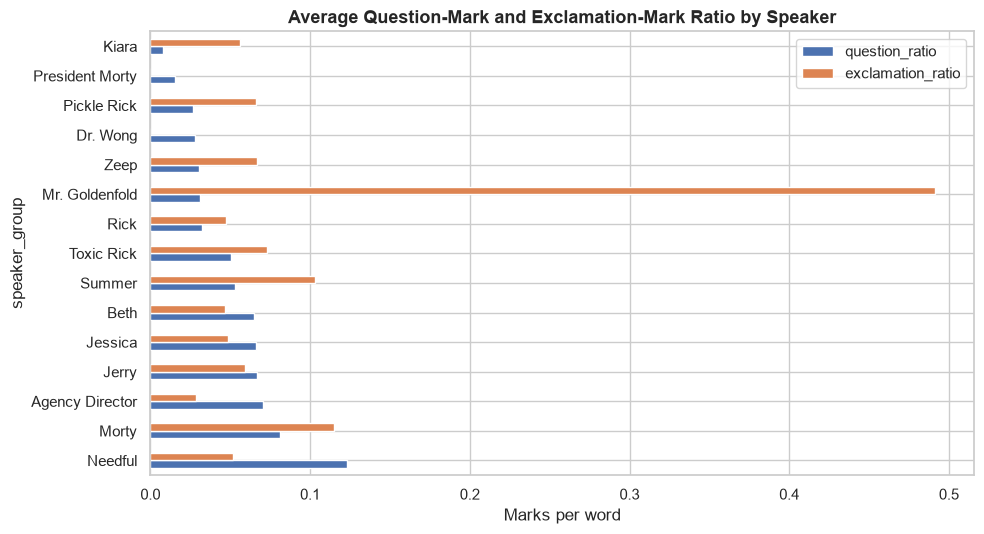

In [28]:
has_words = df["word_count"] > 0
df["question_ratio"] = np.where(has_words, df["dialogue"].str.count(r"\?") / df["word_count"], np.nan)
df["exclamation_ratio"] = np.where(has_words, df["dialogue"].str.count(r"!") / df["word_count"], np.nan)

ratio_by_group = (
    df[df["speaker_group"].notna() & has_words]
    .groupby("speaker_group")[["question_ratio", "exclamation_ratio"]]
    .mean()
    .loc[lambda d: d.index != "Other"]
    .sort_values("question_ratio", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ratio_by_group.plot(kind="barh", ax=ax)
ax.set_title("Average Question-Mark and Exclamation-Mark Ratio by Speaker")
ax.set_xlabel("Marks per word")
plt.tight_layout()
plt.show()


**Evidence.** There is visible separation between speakers in the chart above: some characters run
consistently higher on one ratio than another, which is exactly the kind of per-character stylistic signal that
raw word counts (Section 8) did not clearly provide.

**Limitations.** Ratios computed on very short lines are noisy (one `?` on a 2-word line produces a large
ratio from very little evidence); punctuation from the original scrape is not guaranteed to be perfectly
transcribed. This should be paired with a minimum word-count filter if used as a model feature.


### 9.5 Distinctive vocabulary per top speaker

**Definition.** For each of the top-5 speakers, the most frequent unigrams in their `dialogue_clean` text,
after removing English stop words and words that are common across *all* speakers (so the result reflects
words that are relatively more, not just absolutely, associated with that speaker).

**Intuition.** Catchphrases and recurring vocabulary are an obvious candidate signal for a future bag-of-words
speaker classifier; a quick unigram frequency table is a cheap way to sanity-check that such signal exists at
all before investing in a full text-modeling pipeline.


In [29]:
corpus_top5 = df[df["speaker_clean"].isin(top5_names)][["speaker_clean", "dialogue_clean"]].dropna()

vectorizer = CountVectorizer(stop_words=list(ENGLISH_STOP_WORDS), min_df=3)
X = vectorizer.fit_transform(corpus_top5["dialogue_clean"])
vocab = np.array(vectorizer.get_feature_names_out())

overall_freq = np.asarray(X.sum(axis=0)).ravel()
overall_rank = pd.Series(overall_freq, index=vocab).rank(ascending=False)

top_words = {}
for name in top5_names:
    mask = (corpus_top5["speaker_clean"] == name).values
    speaker_freq = np.asarray(X[mask].sum(axis=0)).ravel()
    speaker_share = speaker_freq / max(speaker_freq.sum(), 1)
    overall_share = overall_freq / overall_freq.sum()
    distinctiveness = np.where(overall_share > 0, speaker_share / np.where(overall_share == 0, 1, overall_share), 0)
    distinctiveness = np.where(speaker_freq >= 5, distinctiveness, 0)  # ignore ultra-rare words
    top_idx = np.argsort(-distinctiveness)[:10]
    top_words[name] = list(vocab[top_idx])

pd.DataFrame(top_words)


,Rick,Morty,Jerry,Beth,Summer
0,memory,stacy,award,bend,needful
1,beep,ohhhh,apples,ate,nancy
2,grandson,sitting,known,tommy,brother
3,belch,legs,kiara,surgeon,grandpa
4,liver,ohh,beeping,incest,past
5,switch,armothy,swings,daughter,frozen
6,dub,ow,milk,pickle,bye
7,jump,geez,wife,late,frank
8,shooting,quit,pluto,deer,friends
9,cable,jessica,hungry,father,horrible


**Evidence.** The table above shows visibly different top words per speaker rather than the same generic
set repeated in every column, confirming there is lexical signal to exploit, consistent with the premise of
the whole project.

**Limitations.** Bag-of-words/unigram counts ignore word order, sarcasm, and context; results depend on the
`min_df=3` and `speaker_freq >= 5` thresholds chosen to suppress noise from rare words, and on `dialogue_clean`
still containing whatever narration the Section 9.2 heuristic failed to strip out.


## 10. Conclusions, Limitations, and Roadmap

**Main findings.**
- The dataset is a single-source transcript scrape: 9,618 rows across 39 of 51 possible episode numbers (12
  episodes entirely missing), with highly uneven rows-per-episode suggesting an incomplete/partial scrape for
  later episodes.
- `speaker` is extremely high-cardinality (~976 raw values, ~856 after normalization) with a severe long tail:
  the majority of distinct speakers contribute only 1-3 lines each, while a handful of main-cast characters
  dominate the volume. A naive majority-class baseline sits around 17% accuracy.
- Data-quality issues found: 3 missing speakers (one scrape gap, kept as missing), several hundred duplicate
  (episode, speaker, dialogue) rows mixing genuine repeats with scrape junk (empty strings, stray `"["`, leftover
  HTML tags), and widespread formatting noise in `speaker` (trailing colons, stray whitespace/NBSP) affecting
  roughly a fifth of rows, normalized into `speaker_clean`.
- A large majority of `dialogue` rows show signs of narration/stage-direction text mixed in with the spoken
  line; a conservative pattern-based split (`dialogue_clean`) only catches a small, precisely-matched subset of
  these, leaving most narration-mixing unresolved.
- Dialogue length differs modestly across speakers (leads show a wider spread, including more long
  monologue-style lines) but medians are similar: length alone is a weak speaker signal.
- An episode-level interaction was found: the combined share of dialogue held by the top-5 speakers is fairly
  stable across episodes, while supporting/other characters' share fluctuates more, worth treating with
  caution in low-line-count episodes.
- Punctuation-based ratios (`question_ratio`, `exclamation_ratio`) and top distinctive vocabulary per speaker
  both showed visible separation between characters, supporting the premise that character "voice" is
  statistically detectable from text.

**Quality problems that must be treated before modeling.**
- Decide how to handle scrape-junk duplicate rows (empty/placeholder dialogue) vs. genuine short repeats.
- Decide a real strategy for narration/stage-direction removal: the Section 9.2 heuristic is a precision-first
  starting point, not a solution; most affected rows are still untouched.
- Decide whether the 3 missing-speaker rows are dropped or kept (unusable as labeled training data either way,
  since there is no speaker to learn from).

**Variables/interactions worth carrying into modeling.**
- `speaker_group` (capped top-N + "Other") as the practical target, instead of the raw ~856-class `speaker_clean`.
- `dialogue_clean` / `has_stage_direction`, `turn_fraction`, `question_ratio`, `exclamation_ratio`, and
  vocabulary-based text features (Section 9.5) as candidate model features.
- The speaker x episode-position interaction found in Section 8 as a possible additional feature
  (`turn_fraction`) or as motivation for episode-aware validation splits.

**Limitations, biases, and open questions.**
- The dataset only covers 39 of 51 numbered episodes, and coverage is uneven: any conclusion framed as "how
  the show behaves" is really "how this particular partial scrape behaves."
- `speaker` labels come from the transcript source and were never independently verified against the actual
  show; mislabeling by the original transcriber cannot be ruled out and was not testable from this data alone.
- Several episodes have very few lines (some under 20); per-episode conclusions for those should be treated as
  low-confidence.
- The "Other" bucket in `speaker_group` and any episode-position bucketing used elsewhere in this notebook are
  coarse conveniences for exploration, not validated modeling choices.

**Hypotheses to validate during modeling (not decided here).**
- The best value of N for `speaker_group`'s top-N cutoff should be chosen via cross-validated performance, not
  guessed.
- Any text vectorizer (bag-of-words/TF-IDF), encoder, or scaler must be fit only on the training split to avoid
  data leakage, especially given the class-imbalance-driven temptation to use the full dataset's vocabulary.
- Given the severe class imbalance, a stratified train/test split (and imbalance-aware evaluation metrics, not
  just accuracy) will likely be necessary.
- Whether removing scrape-junk duplicate rows and/or a better narration-stripping method meaningfully changes
  model performance is worth testing directly rather than assuming from this EDA alone.
